# Classification — Combined Success (IMDb + WOM)



In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v3'
RUN_DIR.mkdir(parents=True, exist_ok=True)
print('Data dir:', DATA_DIR)
print('Run dir: ', RUN_DIR)

Mounted at /content/drive
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6
Run dir:  /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV,
    cross_val_predict, train_test_split, cross_val_score,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


## 2 · Load data

In [ ]:

real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

LEAKAGE = ['budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
           'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_mov = real_mov.drop(columns=LEAKAGE, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE, errors='ignore')

META_KEEP = [
    'movie_id', 'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]
real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left'); real_mov['is_synthetic'] = 0
syn_mov  = syn_mov.merge(syn_meta_sub, on='movie_id', how='left'); syn_mov['is_synthetic'] = 1
df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Combined: {len(df_all)} movies × {len(df_all.columns)} cols')

Combined: 50 movies × 343 cols


# Encode features

In [ ]:

DROP = {'movie_id', 'condition', 'n_participants',
        'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
        'is_synthetic'}
df_feat = df_all.copy()

ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns: df_feat[c] = df_feat[c].map(ORD_MAP)

OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)

feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)

X_all = X_all.drop(columns=X_all.columns[X_all.isna().all()].tolist())
X_all = X_all.drop(columns=X_all.columns[X_all.std() == 0].tolist())
feature_cols = list(X_all.columns)
print(f'Final feature matrix: {X_all.shape}')

Final feature matrix: (50, 360)


# Building the combined success class

In [ ]:
# Combine IMDb and WOM into a single composite score, then threshold at median
z_imdb = (y_imdb_all - y_imdb_all.mean()) / y_imdb_all.std()
z_wom  = (y_wom_all  - y_wom_all.mean())  / y_wom_all.std()
composite = (z_imdb + z_wom) / 2
threshold = composite.median()
y_class_all = (composite >= threshold).astype(int)

print(f'Composite stats:  mean={composite.mean():.3f}, std={composite.std():.3f}')
print(f'Threshold (median): {threshold:.3f}')
print(f'\nClass distribution:')
print(y_class_all.value_counts().sort_index().rename({0:'low',1:'high'}).to_string())
print(f'\nReal-only class distribution:')
print(y_class_all[~synth_mask_all].value_counts().sort_index()
      .rename({0:'low',1:'high'}).to_string())

Composite stats:  mean=0.000, std=0.880
Threshold (median): 0.113

Class distribution:
low     25
high    25

Real-only class distribution:
low     4
high    6


# 80/20 stratified split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_class_all, test_size=0.2, random_state=42,
    stratify=y_class_all,
)
print(f'Train: {len(X_train)} (class balance: {y_train.value_counts(normalize=True).to_dict()})')
print(f'Test:  {len(X_test)}  (class balance: {y_test.value_counts(normalize=True).to_dict()})')
print(f'\nTrain features: {X_train.shape}')
print(f'Test features:  {X_test.shape}')

Train: 40 (class balance: {0: 0.5, 1: 0.5})
Test:  10  (class balance: {0: 0.5, 1: 0.5})

Train features: (40, 360)
Test features:  (10, 360)


# Helper functions

In [ ]:
def evaluate_classifier(estimator, X_train, X_test, y_train, y_test, name=''):
    """Fit on train, predict on test, return metrics + predictions."""
    estimator.fit(X_train, y_train)
    y_pred  = estimator.predict(X_test)
    try:
        y_proba = estimator.predict_proba(X_test)[:, 1]
    except (AttributeError, NotImplementedError):
        try:
            y_proba = estimator.decision_function(X_test)
        except (AttributeError, NotImplementedError):
            y_proba = y_pred.astype(float)
    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba) if len(np.unique(y_test))>1 else float('nan'),
        'n_test':    len(y_test),
    }
    return metrics, y_pred, y_proba

def report_clf(metrics, name):
    print(f'\n──── {name} ────')
    for k, v in metrics.items():
        print(f'  {k:>10s}: {v:.3f}' if isinstance(v, float) else f'  {k:>10s}: {v}')

def tune_and_evaluate(pipeline_factory, param_grid, X_train, y_train, X_test, y_test,
                     scoring='roc_auc', cv_splits=5, name='Model'):
    """GridSearchCV on training set, then evaluate on test."""
    pipe = pipeline_factory()
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    search = GridSearchCV(pipe, param_grid, cv=cv, scoring=scoring,
                         n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    metrics, y_pred, y_proba = evaluate_classifier(best, X_train, X_test, y_train, y_test, name)
    report_clf(metrics, f'{name} (test set)')
    print(f'  Best params: {search.best_params_}')
    return metrics, search.best_params_, y_pred, y_proba

# Train and evaluate all 6 classifiers

# Logistic Regression with Elastic Net (L1+L2)

In [ ]:
from sklearn.linear_model import LogisticRegression

def make_logreg_enet():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(penalty='elasticnet', solver='saga',
                                      max_iter=10000, random_state=42)),
    ])

param_grid = {
    'model__C':        np.logspace(-3, 2, 12).tolist(),
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}
m_enet, p_enet, _, _ = tune_and_evaluate(make_logreg_enet, param_grid,
                                          X_train, y_train, X_test, y_test,
                                          name='LogReg (ElasticNet)')


──── LogReg (ElasticNet) (test set) ────
    accuracy: 0.900
          f1: 0.889
     roc_auc: 0.880
      n_test: 10
  Best params: {'model__C': 0.02310129700083159, 'model__l1_ratio': 0.1}


# Logistic Regression with L2 (Ridge)

In [ ]:
def make_logreg_l2():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(penalty='l2', solver='lbfgs',
                                      max_iter=10000, random_state=42)),
    ])

param_grid = {'model__C': np.logspace(-3, 3, 15).tolist()}
m_l2, p_l2, _, _ = tune_and_evaluate(make_logreg_l2, param_grid,
                                      X_train, y_train, X_test, y_test,
                                      name='LogReg (L2)')


──── LogReg (L2) (test set) ────
    accuracy: 0.900
          f1: 0.889
     roc_auc: 0.880
      n_test: 10
  Best params: {'model__C': 0.001}


# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def make_rf_clf():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])

param_grid = {
    'model__n_estimators':    [200, 500],
    'model__max_depth':       [3, 5, 7, None],
    'model__min_samples_leaf':[1, 2, 4],
    'model__max_features':   ['sqrt', 0.3, 0.5],
}
m_rf, p_rf, _, _ = tune_and_evaluate(make_rf_clf, param_grid,
                                      X_train, y_train, X_test, y_test,
                                      name='Random Forest')


──── Random Forest (test set) ────
    accuracy: 0.900
          f1: 0.889
     roc_auc: 0.800
      n_test: 10
  Best params: {'model__max_depth': 3, 'model__max_features': 0.3, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}


# Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

def make_gbm_clf():
    return Pipeline([
        ('model', HistGradientBoostingClassifier(random_state=42)),
    ])

param_grid = {
    'model__learning_rate':     [0.01, 0.05, 0.1],
    'model__max_iter':          [100, 200, 400],
    'model__max_depth':         [3, 5, None],
    'model__min_samples_leaf':  [4, 10],
    'model__l2_regularization': [0.0, 1.0, 10.0],
}
m_gbm, p_gbm, _, _ = tune_and_evaluate(make_gbm_clf, param_grid,
                                        X_train, y_train, X_test, y_test,
                                        name='Gradient Boosting')


──── Gradient Boosting (test set) ────
    accuracy: 0.800
          f1: 0.800
     roc_auc: 0.760
      n_test: 10
  Best params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400, 'model__min_samples_leaf': 4}


# PLS-DA (PLS Discriminant Analysis)

In [ ]:
# Use PLSRegression with binarytarget, then threshold at 0.5
from sklearn.cross_decomposition import PLSRegression
from sklearn.base import BaseEstimator, ClassifierMixin

class PLSDA(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.pls = PLSRegression(n_components=self.n_components, scale=False)
        self.pls.fit(X, y.astype(float))
        return self
    def predict_proba(self, X):
        score = self.pls.predict(X).flatten()
        score = np.clip(score, 0, 1)
        return np.column_stack([1 - score, score])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

def make_plsda():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', PLSDA(n_components=2)),
    ])

param_grid = {'model__n_components': list(range(1, 16))}
m_pls, p_pls, _, _ = tune_and_evaluate(make_plsda, param_grid,
                                        X_train, y_train, X_test, y_test,
                                        scoring='roc_auc',
                                        name='PLS-DA')


──── PLS-DA (test set) ────
    accuracy: 0.900
          f1: 0.889
     roc_auc: 0.880
      n_test: 10
  Best params: {'model__n_components': 1}


#Gaussian Process Classifier

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern

def make_gpc(kernel_type='rbf'):
    if kernel_type == 'rbf':
        kernel = ConstantKernel(1.0) * RBF(length_scale=1.0,
                                            length_scale_bounds=(1e-2, 1e3))
    elif kernel_type == 'matern25':
        kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5,
                                                length_scale_bounds=(1e-2, 1e3))
    else:
        raise ValueError(kernel_type)
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', GaussianProcessClassifier(kernel=kernel,
                                              n_restarts_optimizer=10,
                                              random_state=42)),
    ])

results_gpc = {}
for kt in ['rbf', 'matern25']:
    pipe = make_gpc(kt)
    pipe.fit(X_train, y_train)
    metrics, _, _ = evaluate_classifier(pipe, X_train, X_test, y_train, y_test,
                                         f'GPC ({kt})')
    results_gpc[kt] = metrics
    report_clf(metrics, f'GPC ({kt}) — test')

# Pick best kernel by ROC-AUC
best_kernel = max(results_gpc, key=lambda k: results_gpc[k].get('roc_auc', 0)
                                              if not np.isnan(results_gpc[k].get('roc_auc', np.nan))
                                              else -1)
m_gpc = results_gpc[best_kernel]
p_gpc = {'model__kernel': best_kernel}
print(f'\nBest GPC kernel: {best_kernel}')


──── GPC (rbf) — test ────
    accuracy: 0.900
          f1: 0.889
     roc_auc: 0.840
      n_test: 10

──── GPC (matern25) — test ────
    accuracy: 0.900
          f1: 0.889
     roc_auc: 0.840
      n_test: 10

Best GPC kernel: rbf


# Comparison of all classification models

Test-set performance ranking (by ROC-AUC):


,accuracy,f1,roc_auc,n_test
LogReg (ElasticNet),0.9,0.889,0.88,10.0
LogReg (L2),0.9,0.889,0.88,10.0
PLS-DA,0.9,0.889,0.88,10.0
GP Classifier,0.9,0.889,0.84,10.0
Random Forest,0.9,0.889,0.80,10.0
Gradient Boosting,0.8,0.800,0.76,10.0


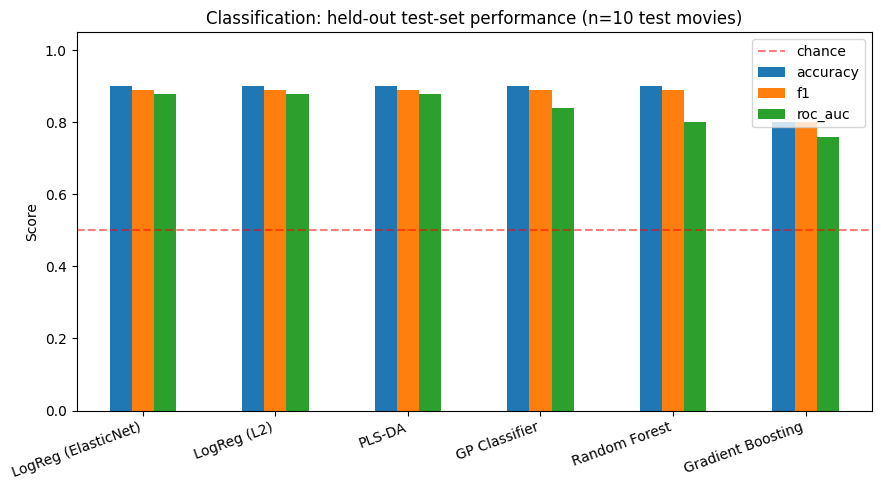

In [ ]:
all_results = {
    'LogReg (ElasticNet)': (m_enet, p_enet),
    'LogReg (L2)':          (m_l2, p_l2),
    'Random Forest':        (m_rf, p_rf),
    'Gradient Boosting':    (m_gbm, p_gbm),
    'PLS-DA':               (m_pls, p_pls),
    'GP Classifier':        (m_gpc, p_gpc),
}

comparison = pd.DataFrame({name: m for name, (m, _) in all_results.items()}).T
comparison = comparison.sort_values('roc_auc', ascending=False)
print('Test-set performance ranking (by ROC-AUC):')
display(comparison.round(3))


fig, ax = plt.subplots(figsize=(9, 5))
comparison[['accuracy', 'f1', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='chance')
ax.set_ylabel('Score')
ax.set_title('Classification: held-out test-set performance (n=10 test movies)')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Confusion matrix for the best classifier

Best classifier on test set: LogReg (ElasticNet)


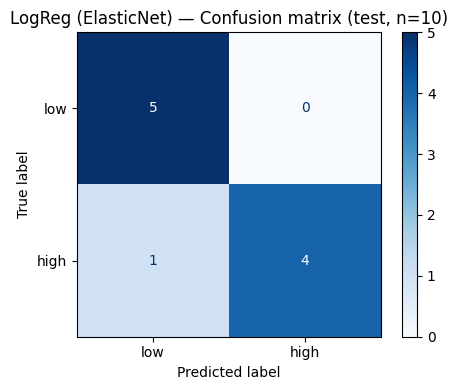


Classification report:
              precision    recall  f1-score   support

         low       0.83      1.00      0.91         5
        high       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



In [ ]:
best_name = comparison.index[0]
print(f'Best classifier on test set: {best_name}')

factories = {
    'LogReg (ElasticNet)': make_logreg_enet,
    'LogReg (L2)':          make_logreg_l2,
    'Random Forest':        make_rf_clf,
    'Gradient Boosting':    make_gbm_clf,
    'PLS-DA':               make_plsda,
    'GP Classifier':        lambda: make_gpc(p_gpc['model__kernel']),
}
factory = factories[best_name]
best_params = all_results[best_name][1]
pipe = factory()
if best_params:
    set_params = {k: v for k, v in best_params.items() if k.startswith('model__')}
    if set_params: pipe.set_params(**set_params)
pipe.fit(X_train, y_train)
y_pred_best = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['low', 'high']).plot(
    ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'{best_name} — Confusion matrix (test, n=10)')
plt.tight_layout(); plt.show()
print('\nClassification report:')
print(classification_report(y_test, y_pred_best, target_names=['low','high'], zero_division=0))

In [ ]:
out = {
    'task': 'binary_classification_combined_success',
    'composite_threshold': float(threshold),
    'class_distribution': y_class_all.value_counts().to_dict(),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'feature_count': len(feature_cols),
    'results_per_model': {name: {'metrics': m, 'best_params': p}
                          for name, (m, p) in all_results.items()},
    'best_model_test': best_name,
}
out_path = RUN_DIR / 'results_classification.json'
with open(out_path, 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved → {out_path}')

Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3/results_classification.json
